# Using the Figshare Data Set

### Import All Necessary Packages

In [1]:
import pickle
import numpy as np
from matplotlib import rc
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression
from scipy.signal import find_peaks
from statsmodels.tsa.stattools import acf

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix, precision_recall_curve, average_precision_score

### GBC Model Training

Process the QM9-All calculation results and getting the QM9-DA set

In [ ]:
# Load the QM9-All calculation results from the figshare data set: https://doi.org/10.6084/m9.figshare.32227395
with open("QM9-All.pkl", "rb") as f:
    qm9_raw_data = pickle.load(f)

print("QM9-All contains a total of", len(qm9_raw_data), 'data points.')
print('Each data point corresponds to a molecule and has', qm9_raw_data[0].shape[0], 'columns, which corresponds to the following descriptors: \nDIIS_Error, Energy, Energy_change, alpha_HOMO-2, alpha_HOMO-1, alpah_HOMO, alpha_LUMO, alphaLUMO+1, alphaLUMO+2, betaHOMO-2, betaHOMO-1, betaHOMO, betaLUMO, betaLUMO+1, betaLUMO+2')

In [ ]:
# Getting the iteration information for each molecule
iter_infos = []
for i in range(len(qm9_raw_data)):
    iter_infos.append(len(qm9_raw_data[i][0]))

# Finding the index for the three cases: Easy, Intermediate, and Difficult
# You can use the Easy and Difficult indecies to form QM9-DA set.
difficult_index = []
easy_index = []
interm_index = []

count = 0
for iter in iter_infos:
    if iter > 1000:
        difficult_index.append(count)
    elif iter <=30:
        easy_index.append(count)
    else:
        interm_index.append(count)
    count += 1

Using the iteration infromation you can reproduce Figure 1. in main text.

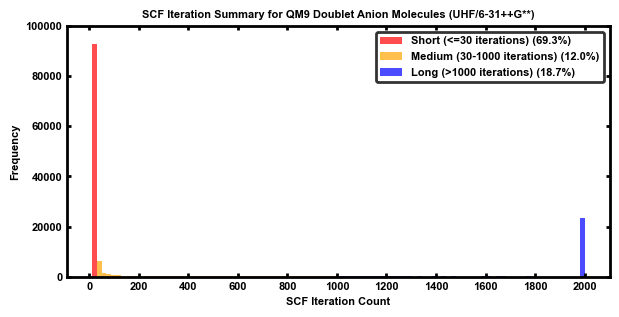

In [ ]:
rc('axes', linewidth=1)
plt.rcParams['pdf.fonttype'] = 42  
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

# === Size Parameters === #
fs = 8         # font size
fs_label = 8   # tick label size
fs_lgd = 8     # legend font size (unused here)
ss = 4         # scatter symbol size
ts = 3         # tick size
slw = 0.5      # scatter line width
lw = 2         # general line width

plt.figure(figsize=(7, 3.25))

easy = np.array(iter_infos)[easy_index]
difficult = np.array(iter_infos)[difficult_index] 
interm = np.array(iter_infos)[interm_index]

counts = np.array([len(easy), len(interm), len(difficult)])
percentages = counts / counts.sum() * 100

# Plot histograms with color coding
plt.hist(easy, bins=1, color='red', alpha=0.7, label=f'Short (<=30 iterations) ({percentages[0]:.1f}%)')
plt.hist(interm, bins=50, color='orange', alpha=0.7, label=f'Medium (30-1000 iterations) ({percentages[1]:.1f}%)')
plt.hist(difficult, bins=50, color='blue', alpha=0.7, label=f'Long (>1000 iterations) ({percentages[2]:.1f}%)')

# Add labels and title
plt.title("SCF Iteration Summary for QM9 Doublet Anion Molecules (UHF/6-31++G**)", fontweight='bold', fontsize=fs)
plt.tick_params(axis='both', which='major', labelsize=fs_label,
                   size=ts, width=2, direction='in', top=True, right=True)

xticks = np.arange(0, 2100, 200)
xlabels = [str(x) for x in xticks]
plt.xticks(xticks, xlabels)

plt.ylim(0, 10000)
yticks = np.arange(0, 105000, 20000)
ylabels = [str(y) for y in yticks]
plt.yticks(yticks, ylabels)

plt.xlabel("SCF Iteration Count")
plt.ylabel("Frequency")
lgnd = plt.legend(frameon=True, fontsize=8, loc="upper right")

# Make background fully transparent
lgnd.get_frame().set_facecolor('none')      
# Add black border
lgnd.get_frame().set_edgecolor('black')
# (Optional) make the border thicker
lgnd.get_frame().set_linewidth(2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

plt.show()

This section demonstrates the feature generation process for the iSmall-train set.
The validation and test sets, as well as the iMedium and iLarge datasets, follow an identical approach.

In [ ]:
# For the classification training, we will select 1000 samples from the easy and difficult cases, respectively, to form the iSmall-train set.
select_easy_s = np.random.choice(easy_index, 1000, replace=False)
select_difficult_s = np.random.choice(difficult_index, 1000, replace=False)

# extract only the first 10 iterations for each molecule in the selected sets, and label them as 1 for difficult and 0 for easy.
first_10_iters_iSmall_train = []
labels_s = []

for ind in select_difficult_s:
    first_10_iters_iSmall_train.append(np.array(list(map(list, zip(*qm9_raw_data[ind]))))[1:11])
    labels_s.append(1)
    
for ind in select_easy_s:
    first_10_iters_iSmall_train.append(np.array(list(map(list, zip(*qm9_raw_data[ind]))))[1:11])
    labels_s.append(0)

In [29]:
def calculate_slope(series):
    x = np.arange(len(series)).reshape(-1, 1)
    reg = LinearRegression().fit(x, series)
    return reg.coef_[0]

def calculate_fluctuation(series):
    """Calculate fluctuation metrics: range, rolling std, local minima/maxima."""
    range_value = np.max(series) - np.min(series)
    rolling_std = pd.Series(series).rolling(window=5).std().mean()  # Rolling std with a window of 5
    peaks, _ = find_peaks(series)
    valleys, _ = find_peaks(-series)
    num_peaks_valleys = len(peaks) + len(valleys)
    
    return range_value, rolling_std, num_peaks_valleys

def calculate_trend_vs_fluctuation_ratio(slope, fluctuation_std):
    """Calculate the ratio of trend (slope) to fluctuation (standard deviation)."""
    return slope / fluctuation_std if fluctuation_std != 0 else 0

def calculate_change_in_trend(series):
    """Calculate the change in trend between the first and second halves of the series."""
    mid_point = len(series) // 2
    slope_first_half = calculate_slope(series[:mid_point])
    slope_second_half = calculate_slope(series[mid_point:])
    return slope_second_half - slope_first_half

def calculate_autocorrelation(series):
    """Calculate autocorrelation for the time series."""
    autocorr_values = acf(series, nlags=1)  # First lag autocorrelation
    return autocorr_values[1] if len(autocorr_values) > 1 else 0

# Generate the 9-statistical features for each time serie in the dataset
def gen_features(series):
    mean = np.mean(series)
    median = np.median(series)
    standev = np.std(series)

    slope = calculate_slope(series)
    fluctuation_range, fluctuation_std, num_peaks_valleys = calculate_fluctuation(series)
    trend_vs_fluctuation_ratio = calculate_trend_vs_fluctuation_ratio(slope, fluctuation_std)
    change_in_trend = calculate_change_in_trend(series)
    autocorrelation = calculate_autocorrelation(series)
    
    return [median, standev, slope, fluctuation_range, fluctuation_std, num_peaks_valleys, trend_vs_fluctuation_ratio, change_in_trend, autocorrelation]

# Generate the feature labels for the 9 features of each time series
def get_feat_names(series):
    labels = []
    for name in series:
        feature_names = [name + r'_Med', name + r'_$\sigma$', name + '_Slope', name + '_Range', name + r'_$\sigma_{rolling}$', name + '_#_Peaks', name + r'_$R_{trend/fluct}$', name + r'_$\Delta$_Slope', name + '_ACF']
        labels.extend(feature_names)
    return np.array(labels)

def extract_features(data):
    num_samples = len(data) 
    descriptors = ['diis', 'En', 'dE', r'$\alpha$_HOMO_2', r'$\alpha$_HOMO_1', r'$\alpha$_HOMO',  r'$\alpha$_LUMO', r'$\alpha$_LUMO_1', r'$\alpha$_LUMO_2', r'$\beta$_HOMO_2', r'$\beta$_HOMO_1', r'$\beta$_HOMO', r'$\beta$_LUMO', r'$\beta$_LUMO_1', r'$\beta$_LUMO_2', r'$\alpha$_gap', r'$\beta$_gap']
    features = []
    for i in range(num_samples):
        sample = data[i].T
        feature_vector = []

        alpha_gap = sample[6] - sample[5]
        beta_gap = sample[12] - sample[11]

        for j in np.linspace(0,14,15).astype(int):
            feature_vector.extend(gen_features(sample[j]))

        feature_vector.extend(gen_features(alpha_gap))
        feature_vector.extend(gen_features(beta_gap))

        features.append(feature_vector)

    return np.array(features), get_feat_names(descriptors)

In [ ]:
# Extract feature set and feature labels for the iSmall-Train
X_iSmall, iSmall_feature_labels = extract_features(first_10_iters_iSmall_train)

In [33]:
# initial evaluation of the GBC using the sub train and sub val set
X_sub_train, X_sub_val, y_sub_train, y_sub_val = train_test_split(X_iSmall, labels_s, test_size=0.2, random_state=42)

model_gb = GradientBoostingClassifier(max_depth=3, random_state=42)

min_max_scaler = MinMaxScaler() 
min_max_scaler.fit(X_sub_train)
X_sub_train_scaled = min_max_scaler.transform(X_sub_train)
model_gb.fit(X_sub_train_scaled, y_sub_train)

X_sub_val_scaled = min_max_scaler.transform(X_sub_val)
y_val_pred = model_gb.predict(X_sub_val_scaled)

print("F1 Score:", f1_score(y_sub_val, y_val_pred))
print("ROC AUC Score:", roc_auc_score(y_sub_val, y_val_pred))

F1 Score: 0.94
ROC AUC Score: 0.9400235005875147


### Performance Evaluations

Having outlined the dataset generation process, we now evaluate model performance using the iMedium train, validation, and test sets.

In [36]:
# Load the iMedium-train, iMedium-val, and iMedium-large data from the figshare data set: https://doi.org/10.6084/m9.figshare.32227395
iMedium_train = pd.read_csv("iMedium_train.csv")
iMedium_val = pd.read_csv("iMedium_val.csv")
iMedium_test = pd.read_csv("iMedium_test.csv")

In [48]:
# Prepare the feature matrices and label vectors for the iMedium-train, iMedium-val, and iMedium-test sets
iMedium_train_X = iMedium_train.iloc[:, 1:7].values
iMedium_train_y = iMedium_train['label'].values
iMedium_val_X = iMedium_val.iloc[:, 1:7].values
iMedium_val_y = iMedium_val['label'].values
iMedium_test_X = iMedium_test.iloc[:, 1:7].values
iMedium_test_y = iMedium_test['label'].values

# Train a Gradient Boosting Classifier on the iMedium-train set
gbc_iMedium = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.8, min_samples_leaf=4, random_state=523)

# Scale only the iMedium-train. iMedium-val and iMedium-test data already scaled and fitted on the training set
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(iMedium_train_X)
iMedium_train_X_scaled = min_max_scaler.transform(iMedium_train_X)

# Train the model on the scaled iMedium-train set
gbc_iMedium.fit(iMedium_train_X_scaled, iMedium_train_y)

p_val  = gbc_iMedium.predict_proba(iMedium_val_X)[:, 1]
precision, recall, thr = precision_recall_curve(iMedium_val_y, p_val)
f1_scores = 2*precision*recall / (precision+recall + 1e-12)
best_thr  = thr[np.argmax(f1_scores)]
print(f"chosen threshold = {best_thr:.3f}")

#Evaluate the model on the iMedium-test set using the chosen threshold
p_test = gbc_iMedium.predict_proba(iMedium_test_X)[:, 1]
y_pred = (p_test >= best_thr).astype(int)
print(confusion_matrix(iMedium_test_y, y_pred))
print(classification_report(iMedium_test_y, y_pred, digits=3))
print("ROC-AUC =", roc_auc_score(iMedium_test_y, p_test),
      " PR-AUC =", average_precision_score(iMedium_test_y, p_test))

chosen threshold = 0.802
[[42519  1361]
 [ 1429  8576]]
              precision    recall  f1-score   support

           0      0.967     0.969     0.968     43880
           1      0.863     0.857     0.860     10005

    accuracy                          0.948     53885
   macro avg      0.915     0.913     0.914     53885
weighted avg      0.948     0.948     0.948     53885

ROC-AUC = 0.9704693505571734  PR-AUC = 0.9176598276926168


Now we are going to evaluate the dynamic approach using out-of-domain set iQM9-hcore. All six test domains can be evlauated in the same approach.

In [ ]:
# Load the iQM9-hcore calculation results from the figshare data set: https://doi.org/10.6084/m9.figshare.32227395

# Note for PySCF domain:
# The PySCF trajectory pickle has 14 feature rows instead of the 15-row
# for TeraChem, because PySCF logs do not contain the DIIS-error row.
# Therefore, feature indices must be shifted by one relative to the
# TeraChem pickles:
#   TeraChem: energy=1, alpha_HOMO=5, alpha_LUMO=6, beta_HOMO-1=10, beta_HOMO=11
#   PySCF:    energy=0, alpha_HOMO=4, alpha_LUMO=5, beta_HOMO-1=9,  beta_HOMO=10
with open("iQM9-hcore.pkl", "rb") as f:
    raw_qm9_hcore_data = pickle.load(f)

In [ ]:
def _get_num_peaks_valleys(series):
    """Helper function to calculate total peaks and valleys."""
    peaks, _ = find_peaks(series)
    valleys, _ = find_peaks(-series)
    return len(peaks) + len(valleys)

def extract_six_features(sample_data):
    """
    Extracts only the 6 targeted features from a molecule's iteration data.

    """
    # 1. Isolate only the specific series we need
    en_series       = sample_data[1]
    alpha_homo      = sample_data[5]
    alpha_lumo      = sample_data[6]
    beta_homo_1     = sample_data[10]
    beta_homo       = sample_data[11]
    
    # 2. Calculate the required gap
    alpha_gap = alpha_lumo - alpha_homo
    
    # 3. Calculate the 6 specific features
    en_peaks       = _get_num_peaks_valleys(en_series)
    a_homo_med     = np.median(alpha_homo)
    a_homo_peaks   = _get_num_peaks_valleys(alpha_homo)
    b_homo_1_med   = np.median(beta_homo_1)
    b_homo_med     = np.median(beta_homo)
    a_gap_med      = np.median(alpha_gap)
    
    # 4. Return as a flat numpy array
    return np.array([
        en_peaks, 
        a_homo_med, 
        a_homo_peaks, 
        b_homo_1_med, 
        b_homo_med, 
        a_gap_med
    ])

def simulate_dynamic_predictions(raw_data, model, thr, feature_generator, start_iter=1):
    """
    Simulates step-by-step predictions for molecules. Stops early if model predicts difficult.
    """
    results = []
    
    for ind in range(len(raw_data)):
        # 1. Transpose data to (total_iterations, features)
        mol_data = np.array(list(map(list, zip(*raw_data[ind]))))
        total_iters = mol_data.shape[0]
        
        stopped_early = False
        exit_step = total_iters
        
        # 2. Iterate through the steps consecutively
        window_size = 10

        # Loop stops exactly so the last 't' leaves a perfect 10-iteration window
        for t in range(start_iter, total_iters - window_size + 1):

            # Slice from current step 't' up to 't + 10'
            current_data = np.array(mol_data[t : t + window_size]).T
            
            # 3. Generate Features
            features = feature_generator(current_data)
            
            # 4. Predict
            features = features.reshape(1, -1) 
            feature_scaled = min_max_scaler.transform(features)

            prediction = model.predict_proba(feature_scaled)[:, 1] >= thr
            
            # 5. Check for Early Exit
            if prediction == 1:
                stopped_early = True
                exit_step = t
                break # Exit the inner loop and move to the next molecule
                
        # Record the outcome for this molecule
        results.append({
            "molecule_index": ind,
            "stopped_early": stopped_early,
            "iterations_used": exit_step,
            "true_label": 1 if total_iters > 1000 else 0  # >1000 iterations is difficult
        })
        
    return pd.DataFrame(results)

In [ ]:
#Getting the dynamic approach results for the iQM9-hcore dataset using the trained GBC model on the iMedium-train set
result = simulate_dynamic_predictions(raw_qm9_hcore_data, gbc_iMedium, best_thr, extract_six_features)

In [75]:
y_pred = result['stopped_early'].astype(int)
y_true = result['true_label'].values

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=3))

[[111  39]
 [  1  49]]
              precision    recall  f1-score   support

           0      0.991     0.740     0.847       150
           1      0.557     0.980     0.710        50

    accuracy                          0.800       200
   macro avg      0.774     0.860     0.779       200
weighted avg      0.883     0.800     0.813       200

